# Longitudinal Pitch Stability Augmentation System (SAS)

This notebook implements and evaluates a Pitch Stability Augmentation System (SAS) using the JSBSim Flight Dynamics Model (FDM).

The Douglas A-4 Skyhawk is a compact, carrier-capable attack aircraft characterized by a highly compact delta-wing design and single turbojet engine. It was designed for the Navy and United States Marine Corps during the 1950s. For more information: https://en.wikipedia.org/wiki/Douglas_A-4_Skyhawk

<div align="center">
    <img src="images/Douglas_A-4E_Skyhawk.jpg" width="480" height="280">
</div>

The baseline aircraft exhibits low natural damping in its short-period dynamics $\zeta_{sp}$, making it prone to unwanted oscillations, high pilot workload or pilot-induced oscillations (PIO). To improve handling qualities, this implementation integrates a pitch rate SAS to increase the damping of the short-period mode.

The primary intent of this design is to:

* Augment the natural pitch damping derivative $M_q$ by feeding back the pitch rate $q$.
* Improve damping ratio $\zeta_{sp} \geq 0.5$, targeting Level 1 flying qualities per MIL-STD-1797B.
* Verify response with elevator doublet test simulation.

## Pitch SAS - Control Design
The design utilizes a feedback topology where the pitch rate $q$ is sensed, scaled, and added to the elevator command $\delta_{e_{cmd}}$.

$$u =  \delta_{e_{cmd}} + \underbrace{K_q \cdot q}_{\text{pitch SAS}}$$
where:
* $K_q$: pitch rate feedback gain
* $u$: control law

## Setting up Flight Dynamics Model (FDM)

Specific modifications inside A-4 FDM:
* A first-order elevator actuator dynamics ($1 / [\tau_a s + 1]$) has been integrated directly into the `<flight_control>`.

* The design is implemented as a standalone system file `pitch_sas.xml` and added within the aircraft `<flight_control>`.

In [ ]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os

# Relative path to the directory where the flight model is stored
PATH_TO_JSBSIM_FILES= "./"

try:
  import jsbsim
  print('JSBSim is installed')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      %pip install jsbsim
      # Download aircraft files
      !wget -P aircraft/A4SAS/ https://raw.githubusercontent.com/JSBSim-Team/jsbsim/refs/heads/master/examples/python/aircraft/A4SAS/A4SAS.xml                   
      !wget -P aircraft/A4SAS/ https://raw.githubusercontent.com/JSBSim-Team/jsbsim/refs/heads/master/examples/python/aircraft/A4SAS/pitch_sas.xml
      !wget -P aircraft/A4SAS/engine https://raw.githubusercontent.com/JSBSim-Team/jsbsim/refs/heads/master/examples/python/aircraft/A4SAS/engine/J52.xml
      !wget -P aircraft/A4SAS/engine https://raw.githubusercontent.com/JSBSim-Team/jsbsim/refs/heads/master/examples/python/aircraft/A4SAS/engine/direct.xml
  else:
     print("Error: JSBSim Python module is not installed")

# Environment directory
print(f'Current working directory: {os.getcwd()}')

In [ ]:
import jsbsim
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration Section ---
# Global variables that must be modified to match your particular need
# The aircraft name
# Note - It should match the exact spelling of the model file
AIRCRAFT_NAME="A4SAS"

# --- JSBSim Initialization ---
# These lines initialize the flight dynamics model.

# Avoid flooding the console with log messages.
jsbsim.FGJSBBase().debug_lvl = 0

# Create a flight dynamics model (FDM) instance.
fdm = jsbsim.FGFDMExec(PATH_TO_JSBSIM_FILES)

# Load the aircraft model
fdm.load_model(AIRCRAFT_NAME)

## Implementation and Simulation

The simulation function loads the aircraft initial conditions, trim at steady level flight, generates elevator doublet test and appends the state responses. Finally, the longitudinal states and control inputs time histories are plotted, comparing responses with and without pitch SAS.

The control design runs inside the aircraft FDM, so the pitch SAS is toggled by switching the property:

* Activate SAS: `fdm['fcs/sas-active-switch'] = 1`
* Deactivate SAS: `fdm['fcs/sas-active-switch'] = 0`

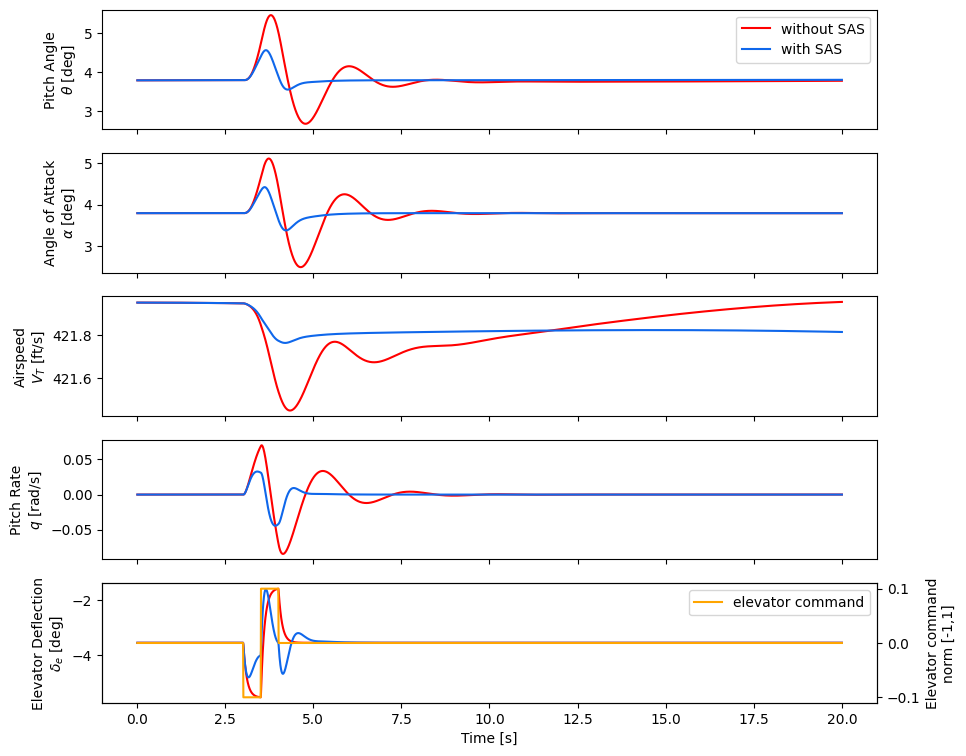

In [13]:
def run_simulation(sas_active):
    # input: sas_activate, 1: activate SAS | 0: deactivate SAS
    # output: data, longitudinal states data
    
    fdm.reset_to_initial_conditions(0)
    # Set engines running
    fdm['propulsion/engine[0]/set-running'] = 1
    # Get the simulation time step (delta time).
    dt = fdm.get_delta_t()
    
    # --- Data Storage ---
    # This section initializes lists to record simulation data.
    data = { 'times':[],
             'thetas': [],
             'alphas': [],
             'airspeeds': [],
             'pitchRates': [],
             'elevator_pos': [],
             'elevator_commands': []
             }

    # --- Simulation Initialization ---
    # This line initializes the flight dynamics model.

    # Initial conditions
    fdm['ic/h-sl-ft']   = 8000 #altitude above sea level (ft)
    fdm['ic/vt-kts']    = 250  #true airspeed (kts)
    fdm['ic/gamma-deg'] = 0    #flight path angle (deg)
    fdm['ic/beta-deg']  = 0    #sideslip angle (deg)

    # Initialize the aircraft with initial conditions
    fdm.run_ic()
    
    # Attempt to trim the aircraft.
    try:
        # 1 means straight flight by using all changeable control variables.   
        fdm['simulation/do_simple_trim'] = 1   
    except jsbsim.TrimFailureError:
        pass  # Ignore trim failure

    # --- Simulation Loop ---
    # This is the main simulation loop that runs the simulation for a specified duration.

    # Time to run for in seconds.
    run_period = 20

    # Doublet command parameters
    doublet_start_time = 3.0 # Starting time of doublet
    doublet_width      = 0.5 # Duration of each pulse in seconds.
    doublet_amplitude  = 0.1 # Magnitude of the elevator deflection, normalized [-1,1]
    
    # Pitch SAS activation
    k_q = 0.869 # default value also defined in system file. Change according to design.
    fdm['fcs/pitch-sas-kq'] = k_q
    fdm['fcs/sas-active-switch'] = sas_active

    for i in range(int(run_period/dt)):
        # Advance the simulation by one time step.
        fdm.run()
        
        # Record the simulation data.
        data['times'].append(fdm.get_sim_time())
        data['thetas'].append(fdm['attitude/theta-deg'])
        data['alphas'].append(fdm['aero/alpha-deg'])
        data['airspeeds'].append(fdm['velocities/vt-fps'])
        data['pitchRates'].append(fdm['velocities/q-rad_sec']) 
        data['elevator_commands'].append(fdm['fcs/elevator-cmd-norm'])
        data['elevator_pos'].append(fdm['fcs/elevator-pos-deg'])
        
        # Get the current simulation time
        current_time = fdm.get_sim_time()

        # Doublet Logic: three distinct phases
        # Phase A: pitch up input
        if doublet_start_time <= current_time < (doublet_start_time + doublet_width):
            elevator_cmd = -doublet_amplitude

        # Phase B: pitch down input
        elif (doublet_start_time + doublet_width) <= current_time < (doublet_start_time + 2 * doublet_width):
            elevator_cmd = doublet_amplitude

        # Phase C: Return to neutral
        else:
            elevator_cmd = 0.0

        # Apply the command to the elevator property
        fdm['fcs/elevator-cmd-norm'] = elevator_cmd
    
    return data

# Run simulations with and without SAS and obtain output data
data_no_sas   = run_simulation(sas_active = 0)
data_with_sas = run_simulation(sas_active = 1)

# --- Plot Results ---
# This section plots the simulation results
fig, axes = plt.subplots(5,1,figsize=(10,9),sharex=True)
ax_theta, ax_alpha, ax_vt, ax_q, ax_elev = axes

color1 = "#0F67EB"
color2 = "#FF0000"
lw1 = 1.5
lw2 = 1.5
# setup individual lines and labels - without SAS
ax_theta.plot(data_no_sas['times'],data_no_sas['thetas'], color= color2, linewidth=lw1, label="without SAS")
ax_alpha.plot(data_no_sas['times'],data_no_sas['alphas'], color= color2,linewidth=lw1)
ax_vt.plot(data_no_sas['times'],data_no_sas['airspeeds'], color= color2,linewidth=lw1)
ax_q.plot(data_no_sas['times'],data_no_sas['pitchRates'], color= color2,linewidth=lw1)
ax_elev.plot(data_no_sas['times'],data_no_sas['elevator_pos'], color= color2,linewidth=lw1)

# setup individual lines and labels - with SAS
ax_theta.plot(data_with_sas['times'],data_with_sas['thetas'], color= color1, linewidth=lw1, label="with SAS")
ax_alpha.plot(data_with_sas['times'],data_with_sas['alphas'], color= color1,linewidth=lw1)
ax_vt.plot(data_with_sas['times'],data_with_sas['airspeeds'], color= color1,linewidth=lw1)
ax_q.plot(data_with_sas['times'],data_with_sas['pitchRates'], color= color1,linewidth=lw1)
ax_elev.plot(data_with_sas['times'],data_with_sas['elevator_pos'], color= color1,linewidth=lw1)

ax_elev.set_xlabel("Time [s]")
ax_theta.legend(loc='upper right')  

# Create a secondary y-axis for the control input command
ax2 = ax_elev.twinx()
ax2.plot(data_no_sas['times'], data_no_sas['elevator_commands'], color='orange', label="elevator command")
ax2.set_ylabel("Elevator command" + "\n" + "norm [-1,1]")
ax2.legend()

# Create labels for the results
labels = ["Pitch Angle" + "\n" + r"$\theta$ [deg]", "Angle of Attack" + "\n" + r"$\alpha$ [deg]", 
          "Airspeed" + "\n" + r"$V_T$ [ft/s]", "Pitch Rate" + "\n" + r"$q$ [rad/s]", 
          "Elevator Deflection" + "\n" + r"$\delta_e$ [deg]"]
for ax,label in zip(axes, labels):
    ax.set_ylabel(label)

# Display the plot
plt.show()

## Linear Stability Analysis - Short period mode

To analytically verify the performance observed above, the linear state-space representation of the longitudinal dynamics is obtained. This allows us to map the stability and control derivatives directly to the system's natural frequency $\omega_{sp}$ and damping ratio $\zeta_{sp}$.

### Longitudinal State-Space Representation
The linear longitudinal dynamics are governed by the system matrix $A_{long}$ and input matrix $B_{long}$ with state vector $\mathbf{x} = [V_a, \alpha, \theta, q]^T$ (airspeed, angle of attack, pitch angle, and pitch rate):

<br>

$$\begin{bmatrix}
\dot{V}_a \\
\dot{\alpha} \\
\dot{\theta} \\
\dot{q}
\end{bmatrix}
=
\begin{bmatrix}
X_V & X_\alpha & -g \cos\theta_0 & X_q \\
Z_V/U_0  & Z_\alpha/U_0  & -g \sin\theta_0/U_0 & 1 + Z_q/U_0 \\
0 & 0 & 0 & 1 \\
M_V & M_\alpha & 0 & M_q
\end{bmatrix}
\begin{bmatrix}
V_a \\
\alpha \\
\theta \\
q
\end{bmatrix}
+
\begin{bmatrix}
X_{\delta_e}\\
Z_{\delta_e}/U_0\\
0\\
M_{\delta_e}
\end{bmatrix}
\delta_e$$
<br>

Where the matrix elements represent the stability and control derivatives extracted via linearization at the trim point.

In [14]:
# set back FDM after trim condition
fdm.reset_to_initial_conditions(0)
# Linearization of FDM
lin = jsbsim.FGLinearization(fdm)
print(f"\nFull state vector:\n X = {lin.x_names}")
# Extract A and B matrices
A = lin.system_matrix
B = lin.input_matrix
# Longitudinal dynamics linear system 
# A_long: 4x4 system matrix
# B_long: 4x1 delta_elevator input matrix
A_long = A[0:4, 0:4]
B_long = B[0:4,[2]]
# Airspeed flight condition and stability derivatives
U0 = A[11,2]
M_q = A_long[3,3]
M_alpha = A_long[3,1]
Z_alpha = A_long[1,1]*U0
Z_q = 0
print(f"\nSystem matrix:\n A =\n {A_long}")
print(f"\nInput matrix:\n B =\n {B_long}")


Full state vector:
 X = ('Vt', 'Alpha', 'Theta', 'Q', 'Beta', 'Phi', 'P', 'Psi', 'R', 'Latitude', 'Longitude', 'Alt')

System matrix:
 A =
 [[-2.48606226e-02  2.67409962e+01 -3.20628503e+01  0.00000000e+00]
 [-2.27269492e-04 -8.76129531e-01  2.08166817e-13  1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 4.30438520e-04 -5.87689252e+00  2.93662664e-09 -8.30470321e-01]]

Input matrix:
 B =
 [[ 1.01081943e-01]
 [-6.47076443e-04]
 [ 0.00000000e+00]
 [-2.26662098e+00]]


### Short-Period Approximation

To analyze the longitudinal dynamics relevant to the pitch SAS, the short-period approximation is used (with state vector $\mathbf{x}_{sp}$ = $[\alpha, q]^T$) to obtain a second order system with characteristic equation defined as:

$$s^2 + 2\zeta_{sp}\omega_{sp}s + \omega_{sp}^2 = 0$$


Applying this approximation yields the analytical equations for natural frequency $\omega_{sp}$ and damping ratio $\zeta_{sp}$ directly from the aircraft's stability derivatives:

<br>

$$\omega_{sp} = \sqrt{\frac{M_q Z_\alpha}{U_0} - M_\alpha} \qquad  \qquad \zeta_{sp} = -\frac{M_q + Z_\alpha/U_0}{2\omega_{sp}}$$



In [15]:
# Obtaining natural frequency and damping ratio
wn_sp = np.sqrt(M_q*Z_alpha/U0 - M_alpha)
zeta_sp = -(M_q + Z_alpha/U0)/(2*wn_sp)

print("Open Loop short-period parameters:\n")
print(f"Natural Frequency: {wn_sp:.3f} rad/s")
print(f"Damping Ratio: {zeta_sp:.3f}")

Open Loop short-period parameters:

Natural Frequency: 2.570 rad/s
Damping Ratio: 0.332


### Closed-Loop Pitch SAS Short-Period Approximation 

By substituting the control law $u$ into the linear system, the pitch damping derivative $M_q$ is affected:
$$M_q^{*} = M_q + M_{\delta_e} K_q$$

Consequently, the closed-loop natural frequency and damping ratio increases analytically as a direct function of the feedback gain $K_q$:

$$\omega_{sp}^{*} = \sqrt{\frac{(M_q + M_{\delta_e} K_q) Z_\alpha}{U_0} - M_\alpha} \qquad  \qquad \zeta_{sp}^{*} = -\frac{(M_q + M_{\delta_e} K_q) + Z_\alpha/U_0}{2\omega_{sp}^{*}}$$



In [16]:
# Obtain default pitch rate feedback gain. Change according to design.
k_q = fdm['fcs/pitch-sas-kq']
# Control derivative
M_de = B_long[3][0]
# Obtain natural frequency and damping ratio with Mq augmented
wn_sp_cl = np.sqrt((M_q + M_de*k_q)*Z_alpha/U0 - M_alpha)
zeta_sp_cl = -(M_q + M_de*k_q + Z_alpha/U0)/(2*wn_sp_cl)

print("Closed-Loop short-period parameters:\n")
print(f"Natural Frequency: {wn_sp_cl:.3f} rad/s")
print(f"Damping Ratio: {zeta_sp_cl:.3f}")

Closed-Loop short-period parameters:

Natural Frequency: 2.886 rad/s
Damping Ratio: 0.637
